# Планировщик траектории квадрокоптера через differential flatness

In [1]:
import time
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation


In [ ]:
N_student = 5  
M = 10 + N_student  
T = 5.0
g = 9.81

p_start = np.array([0.0, 0.0, 0.0])
p_goal = np.array([3.0, 2.0, 1.5])

euler_start_deg = np.array([0.0, 8.0, 0.0])
euler_goal_deg = np.array([-5.0, -10.0, 35.0])

R_start = Rotation.from_euler("xyz", euler_start_deg, degrees=True).as_matrix()
R_goal = Rotation.from_euler("xyz", euler_goal_deg, degrees=True).as_matrix()


def acceleration_from_orientation(R, g=9.81):
    b3 = R[:, 2]
    if b3[2] <= 0.15:
        raise ValueError("Слишком большой наклон")
    thrust = g / b3[2]
    return thrust * b3 - np.array([0.0, 0.0, g])


def smooth_yaw_profile(yaw_start, yaw_goal, K):
    s = np.linspace(0.0, 1.0, K)
    blend = 10 * s**3 - 15 * s**4 + 6 * s**5
    return yaw_start + (yaw_goal - yaw_start) * blend


def recover_orientations(acceleration, yaw, g=9.81):
    e3 = np.array([0.0, 0.0, 1.0])
    rotations = []

    for a_i, yaw_i in zip(acceleration, yaw):
        b3 = a_i + g * e3
        b3 = b3 / np.linalg.norm(b3)

        x_c = np.array([np.cos(yaw_i), np.sin(yaw_i), 0.0])
        b2 = np.cross(b3, x_c)
        if np.linalg.norm(b2) < 1e-8:
            x_c = np.array([np.cos(yaw_i + 1e-3), np.sin(yaw_i + 1e-3), 0.0])
            b2 = np.cross(b3, x_c)
        b2 = b2 / np.linalg.norm(b2)
        b1 = np.cross(b2, b3)

        rotations.append(np.column_stack((b1, b2, b3)))

    return np.array(rotations)


def draw_quadrotor(ax, position, rotation_matrix, arm_length=0.18, color="tab:orange"):
    center = position
    arm_x = arm_length * rotation_matrix[:, 0]
    arm_y = arm_length * rotation_matrix[:, 1]

    p1, p2 = center - arm_x, center + arm_x
    p3, p4 = center - arm_y, center + arm_y

    ax.plot(*np.vstack((p1, p2)).T, color=color, linewidth=2)
    ax.plot(*np.vstack((p3, p4)).T, color=color, linewidth=2)
    ax.scatter(*np.vstack((p1, p2, p3, p4)).T, color="black", s=12)


def solve_flat_trajectory(M_intermediate, T, p_start, p_goal, R_start, R_goal, g=9.81):
    K = M_intermediate + 2
    dt = T / (K - 1)

    a_start = acceleration_from_orientation(R_start, g)
    a_goal = acceleration_from_orientation(R_goal, g)

    p = cp.Variable((K, 3))
    v = cp.Variable((K, 3))
    a = cp.Variable((K, 3))
    j = cp.Variable((K - 1, 3))

    constraints = []
    for k in range(K - 1):
        constraints += [
            p[k + 1] == p[k] + v[k] * dt + 0.5 * a[k] * dt**2 + (1.0 / 6.0) * j[k] * dt**3,
            v[k + 1] == v[k] + a[k] * dt + 0.5 * j[k] * dt**2,
            a[k + 1] == a[k] + j[k] * dt,
        ]

    constraints += [
        p[0] == p_start,
        p[-1] == p_goal,
        v[0] == np.zeros(3),
        v[-1] == np.zeros(3),
        a[0] == a_start,
        a[-1] == a_goal,
    ]

    objective = cp.Minimize(
        cp.sum_squares(j) + 1e-3 * cp.sum_squares(a) + 1e-4 * cp.sum_squares(v)
    )
    problem = cp.Problem(objective, constraints)

    t_start = time.perf_counter()
    problem.solve(solver=cp.OSQP, warm_start=True, verbose=False)
    elapsed = time.perf_counter() - t_start

    if problem.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver status: {problem.status}")

    num_variables = p.size + v.size + a.size + j.size

    yaw_start = np.deg2rad(Rotation.from_matrix(R_start).as_euler("xyz", degrees=True)[2])
    yaw_goal = np.deg2rad(Rotation.from_matrix(R_goal).as_euler("xyz", degrees=True)[2])
    yaw = smooth_yaw_profile(yaw_start, yaw_goal, K)
    rotations = recover_orientations(a.value, yaw, g)
    euler_deg = Rotation.from_matrix(rotations).as_euler("xyz", degrees=True)

    return {
        "K": K,
        "dt": dt,
        "time": elapsed,
        "status": problem.status,
        "objective": problem.value,
        "num_variables": num_variables,
        "p": p.value,
        "v": v.value,
        "a": a.value,
        "j": j.value,
        "yaw": yaw,
        "R": rotations,
        "euler_deg": euler_deg,
    }


In [3]:
solution = solve_flat_trajectory(M, T, p_start, p_goal, R_start, R_goal, g=g)

p_opt = solution["p"]
v_opt = solution["v"]
a_opt = solution["a"]
j_opt = solution["j"]
euler_opt_deg = solution["euler_deg"]
time_grid = np.linspace(0.0, T, solution["K"])

print(f"Статус оптимизации: {solution['status']}")
print(f"Целевая функция: {solution['objective']:.6f}")
print(f"Число переменных: {solution['num_variables']}")
print(f"Время решения: {solution['time'] * 1000:.2f} мс")
print()
print("Промежуточные положения робота (x, y, z):")
print(np.round(p_opt[1:-1], 3))
print()
print("Восстановленные ориентации для этих точек (roll, pitch, yaw) в градусах:")
print(np.round(euler_opt_deg[1:-1], 3))


Статус оптимизации: optimal
Целевая функция: 22.164498
Число переменных: 201
Время решения: 66.02 мс

Промежуточные положения робота (x, y, z):
[[0.058 0.003 0.003]
 [0.195 0.026 0.023]
 [0.37  0.081 0.072]
 [0.558 0.175 0.154]
 [0.745 0.308 0.268]
 [0.926 0.477 0.412]
 [1.105 0.675 0.575]
 [1.289 0.891 0.75 ]
 [1.486 1.114 0.925]
 [1.703 1.331 1.088]
 [1.944 1.531 1.232]
 [2.205 1.702 1.346]
 [2.473 1.838 1.428]
 [2.725 1.932 1.477]
 [2.919 1.985 1.497]]

Восстановленные ориентации для этих точек (roll, pitch, yaw) в градусах:
[[-1.2010e+00  4.4750e+00 -1.6000e-02]
 [-1.9180e+00  2.1000e+00  4.9100e-01]
 [-2.2730e+00  6.6900e-01  1.6800e+00]
 [-2.3370e+00 -1.2000e-02  3.6240e+00]
 [-2.1420e+00 -1.3500e-01  6.3050e+00]
 [-1.6960e+00  1.0400e-01  9.6290e+00]
 [-1.0150e+00  5.0800e-01  1.3432e+01]
 [-1.5300e-01  8.8100e-01  1.7498e+01]
 [ 7.8100e-01  1.0560e+00  2.1573e+01]
 [ 1.6250e+00  9.0200e-01  2.5393e+01]
 [ 2.1840e+00  3.3700e-01  2.8713e+01]
 [ 2.2580e+00 -6.8200e-01  3.1350e+01

## Масштабирование по числу промежуточных точек

Как меняются размер задачи и время вычислений при увеличении числа промежуточных точек в `2` и `10` раз.


In [4]:
benchmark_rows = []

for label, M_test in [("M", M), ("2M", 2 * M), ("10M", 10 * M)]:
    result = solve_flat_trajectory(M_test, T, p_start, p_goal, R_start, R_goal, g=g)
    benchmark_rows.append((label, M_test, result["K"], result["num_variables"], 1000 * result["time"]))

header = f"{'Случай':<6} {'M':>6} {'K=M+2':>8} {'Переменных':>12} {'Время, мс':>12}"
print(header)
print('-' * len(header))
for label, M_test, K_test, num_vars, time_ms in benchmark_rows:
    print(f"{label:<6} {M_test:>6d} {K_test:>8d} {num_vars:>12d} {time_ms:>12.2f}")


Случай      M    K=M+2   Переменных    Время, мс
------------------------------------------------
M          15       17          201        86.95
2M         30       32          381       101.32
10M       150      152         1821       587.67


## Графики траектории

Слева показан путь центра масс и несколько восстановленных ориентаций, справа нормы скорости, ускорения и рывка.


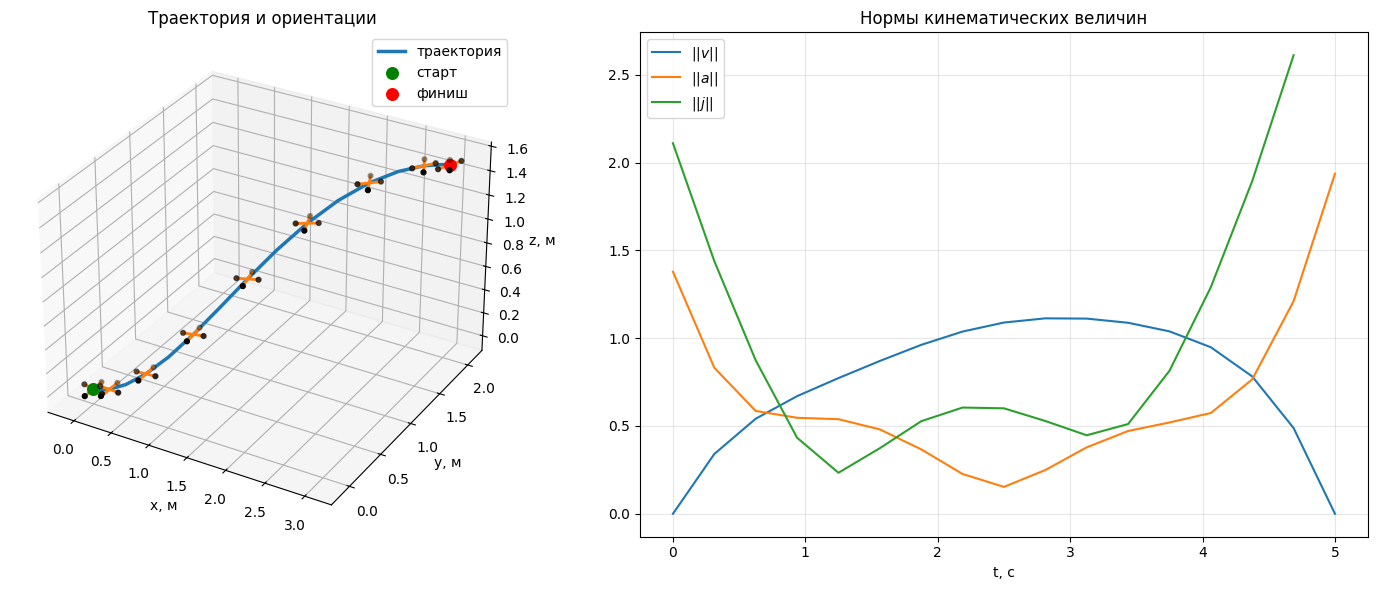

In [5]:
fig = plt.figure(figsize=(15, 6))

ax_path = fig.add_subplot(1, 2, 1, projection="3d")
ax_path.plot(p_opt[:, 0], p_opt[:, 1], p_opt[:, 2], linewidth=2.5, color="tab:blue", label="траектория")
ax_path.scatter(*p_opt[0], color="green", s=70, label="старт")
ax_path.scatter(*p_opt[-1], color="red", s=70, label="финиш")

pose_step = max(1, solution["K"] // 6)
for idx in range(0, solution["K"], pose_step):
    draw_quadrotor(ax_path, p_opt[idx], solution["R"][idx], arm_length=0.12)

ax_path.set_title("Траектория и ориентации")
ax_path.set_xlabel("x, м")
ax_path.set_ylabel("y, м")
ax_path.set_zlabel("z, м")
ax_path.legend()

ax_norms = fig.add_subplot(1, 2, 2)
ax_norms.plot(time_grid, np.linalg.norm(v_opt, axis=1), label=r"$||v||$")
ax_norms.plot(time_grid, np.linalg.norm(a_opt, axis=1), label=r"$||a||$")
ax_norms.plot(time_grid[:-1], np.linalg.norm(j_opt, axis=1), label=r"$||j||$")
ax_norms.set_title("Нормы кинематических величин")
ax_norms.set_xlabel("t, c")
ax_norms.grid(True, alpha=0.3)
ax_norms.legend()

plt.tight_layout()
plt.show()


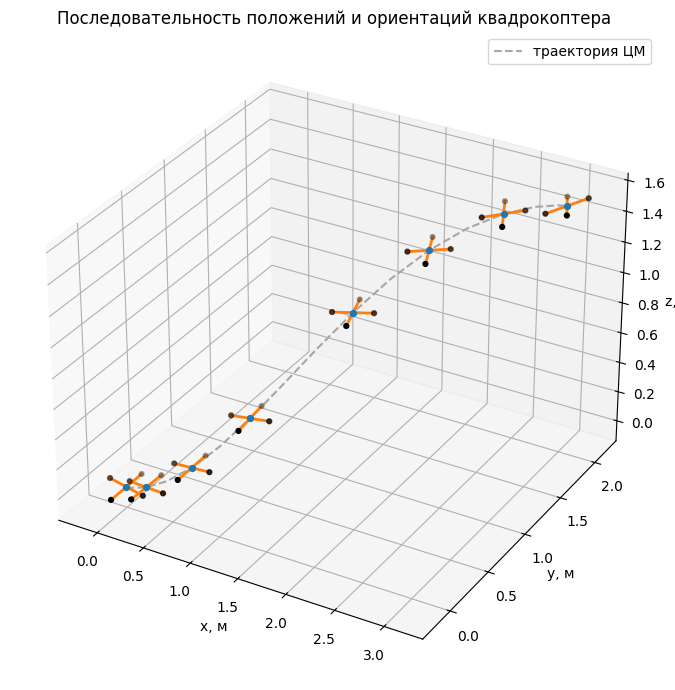

In [6]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(p_opt[:, 0], p_opt[:, 1], p_opt[:, 2], linestyle="--", color="0.65", label="траектория ЦМ")

indices = np.linspace(0, solution["K"] - 1, 8, dtype=int)
for idx in indices:
    draw_quadrotor(ax, p_opt[idx], solution["R"][idx], arm_length=0.18)
    ax.scatter(*p_opt[idx], color="tab:blue", s=18)

ax.set_title("Последовательность положений и ориентаций квадрокоптера")
ax.set_xlabel("x, м")
ax.set_ylabel("y, м")
ax.set_zlabel("z, м")
ax.legend()
plt.tight_layout()
plt.show()
